STEP 1. 데이터 불러오기
Train : 930명  |  Test : 233명
전체 피처 : 18개  →  Cox 피처 : 14개

Cox 피처 목록 (14개):
  Age
  Sex
  Prior_cancer
  Grade_G2
  Grade_G3
  Grade_G4
  Site_BrainNOS
  Site_Cerebrum
  Site_Other
  Era_After2005
  Era_Before2005
  Tx_Single
  Tx_Standard
  Tx_None

STEP 2. 단변량 Cox 분석
      Variable    HR        95% CI  p-value Significant
           Age 1.059 1.052 – 1.066   0.0000         ***
      Grade_G2 0.112 0.077 – 0.164   0.0000         ***
      Grade_G3 0.442 0.343 – 0.568   0.0000         ***
      Grade_G4 6.793 5.400 – 8.545   0.0000         ***
 Site_BrainNOS 5.257 4.180 – 6.612   0.0000         ***
 Site_Cerebrum 0.191 0.150 – 0.242   0.0000         ***
 Era_After2005 0.627 0.523 – 0.751   0.0000         ***
Era_Before2005 1.595 1.332 – 1.911   0.0000         ***
     Tx_Single 3.223 2.331 – 4.458   0.0000         ***
   Tx_Standard 0.377 0.284 – 0.500   0.0000         ***
           Sex 1.222 1.025 – 1.457   0.0251           *
       Tx_None 1.654 0.986 – 2.774   0.05

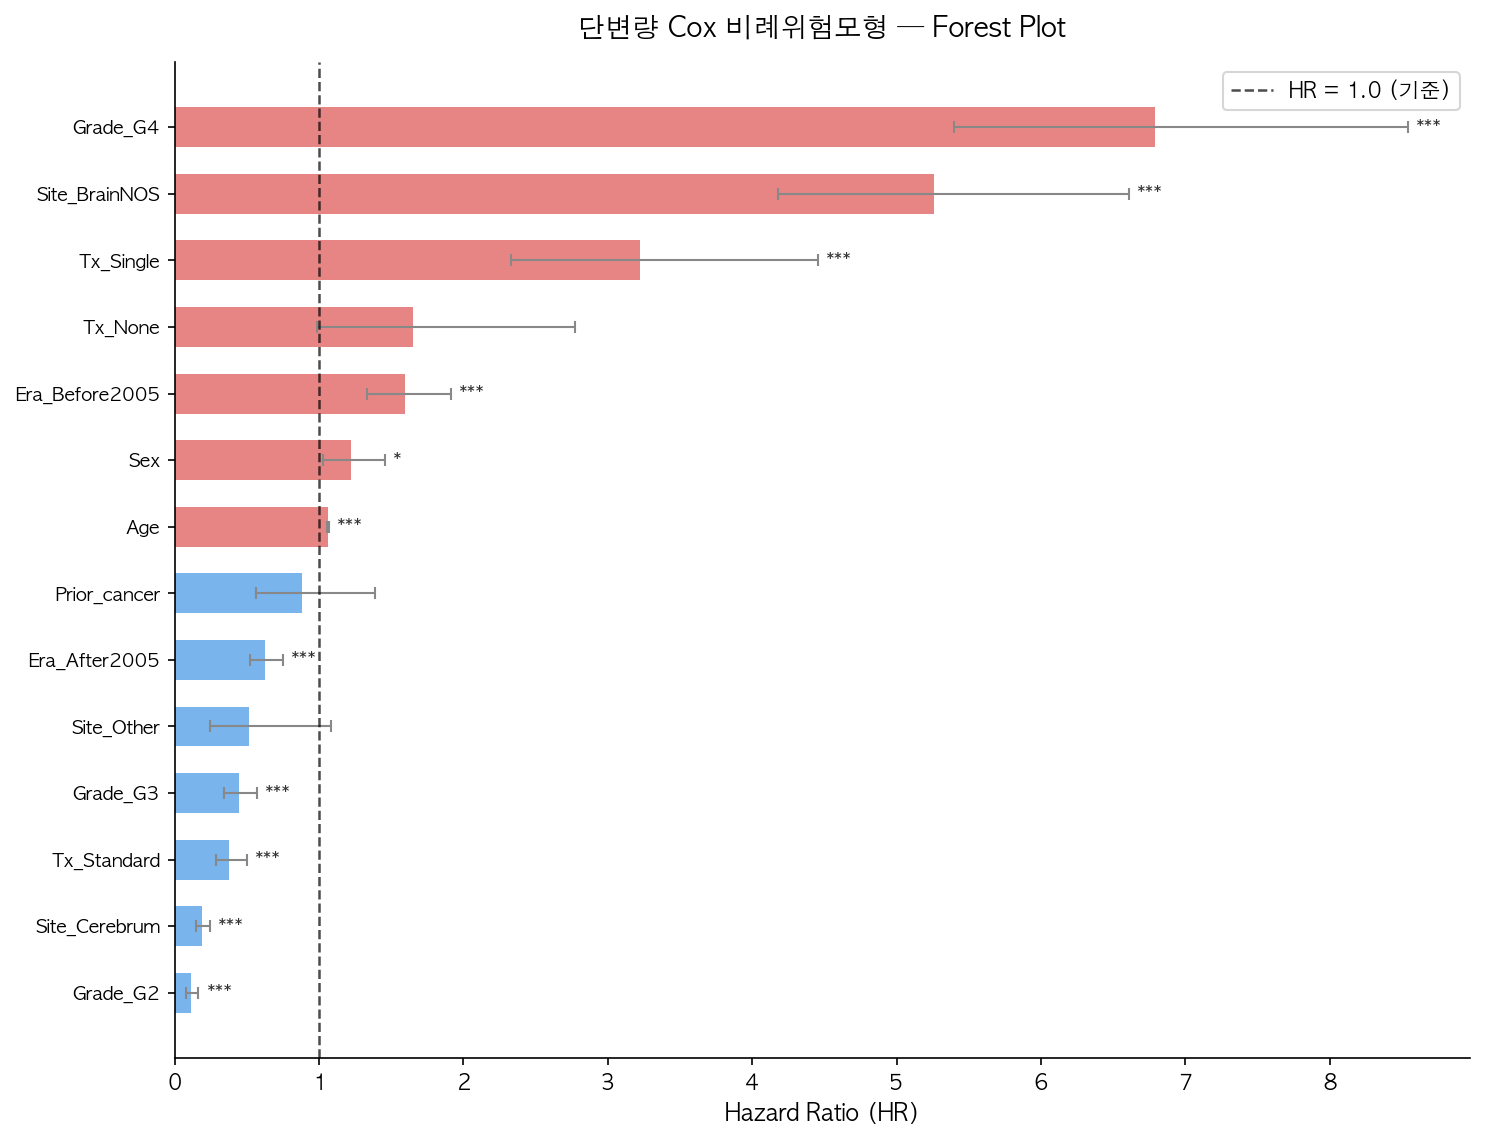

✓ fig_univariate_forest_plot.png 저장 완료

STEP 3. VIF 다중공선성 검정
      Variable  VIF
      Grade_G4 5.89
 Site_Cerebrum 4.87
      Grade_G3 1.59
           Age 1.32
    Site_Other 1.13
Era_Before2005 1.12
     Tx_Single 1.06
  Prior_cancer 1.03
       Tx_None 1.02
           Sex 1.01

✓ table_vif.csv 저장 완료

✓ VIF > 10 변수 없음 — 다중공선성 문제 없음


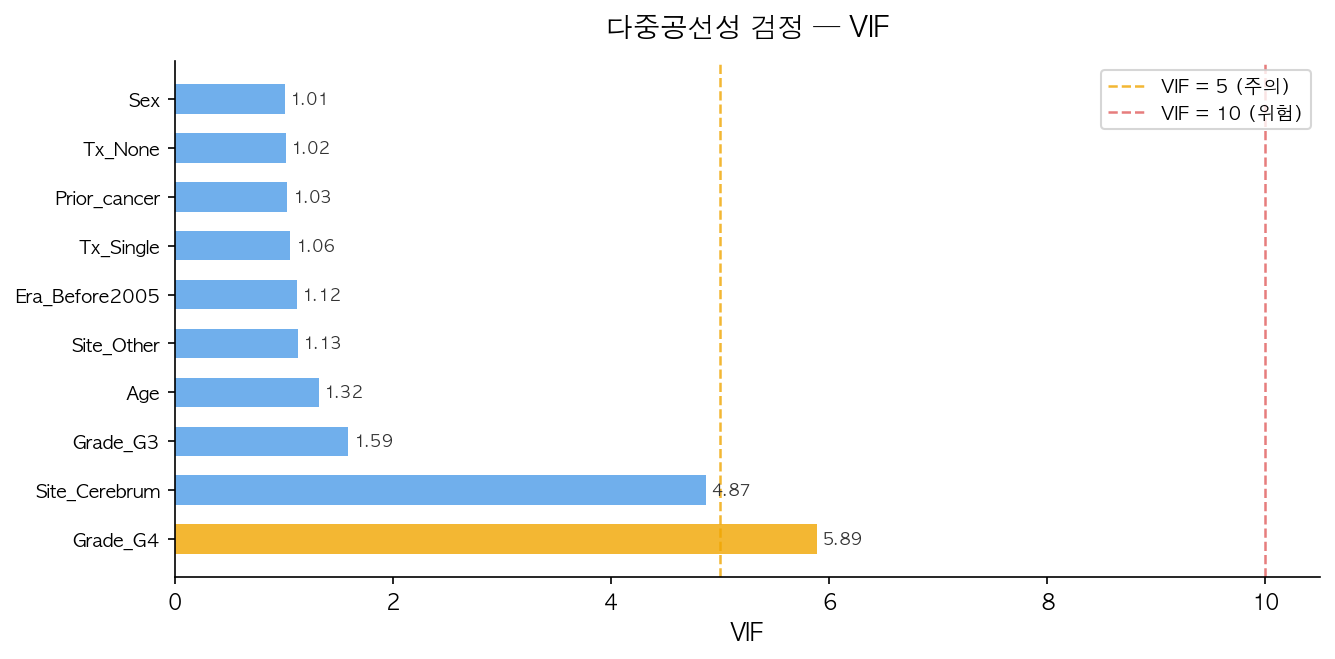

✓ fig_vif.png 저장 완료

기준 범주 제외  : ['Grade_G2', 'Site_BrainNOS', 'Era_After2005', 'Tx_Standard']

다변량 포함 변수 (10개):
  Age
  Sex
  Prior_cancer
  Grade_G3
  Grade_G4
  Site_Cerebrum
  Site_Other
  Era_Before2005
  Tx_Single
  Tx_None

STEP 3.5. Grid Search CV — 최적 penalizer 탐색
모든 모델 방법론 통일: Grid Search + 5-Fold CV
탐색 범위: [0.001, 0.005, 0.01, 0.05, 0.1, 0.3, 0.5, 1.0]
총 8개 × 5-Fold = 40번 학습

  alpha=0.001  →  CV C-index: 0.783 ± 0.015
  alpha=0.005  →  CV C-index: 0.783 ± 0.016
  alpha=0.010  →  CV C-index: 0.783 ± 0.016
  alpha=0.050  →  CV C-index: 0.783 ± 0.017
  alpha=0.100  →  CV C-index: 0.782 ± 0.017
  alpha=0.300  →  CV C-index: 0.780 ± 0.018
  alpha=0.500  →  CV C-index: 0.778 ± 0.019
  alpha=1.000  →  CV C-index: 0.776 ± 0.018

✓ 최적 penalizer : 0.01
✓ CV C-index     : 0.783 ± 0.016
✓ table_cox_gridsearch.csv 저장 완료

STEP 4. 다변량 Cox 분석 (penalizer=0.01)
✓ 컬럼 확인 완료 (10개)


<lifelines.CoxPHFitter: fitted with 930 total observations, 403 right-censored observations>
             duration col = 'time'
                event col = 'event'
                penalizer = 0.01
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 930
number of events observed = 527
   partial log-likelihood = -2869.17
         time fit was run = 2026-03-27 04:08:48 UTC

---
                coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                       
Age             0.04      1.04      0.00            0.03            0.05                1.03                1.05
Sex             0.21      1.24      0.09            0.04            0.39                1.04                1.48
Prior_cancer   -0.29      0.75      0.23           -0.74            0.17                0.48                1.18
Grade_G3        0.94      2.55      0.20            0.54            1.33                1.72                3.78
Grade_G4        1.79      5.99      0.25            1.29            2.29                3.64                9.84
Site_Cerebrum  -0.24      0.78      0.23           -0.70            0.21                0.50                1.24
Site_Other      0.00      1.00      0.39           -0.76            0.76                0.47                2.14
Era_Before2005  0.18      1.19      0.10           -0.01            0.37                0.99                1.45
Tx_Single       0.78      2.19      0.17            0.45            1.12                1.57                3.05
Tx_None        -0.13      0.88      0.27           -0.65            0.40                0.52                1.49

                cmp to     z      p  -log2(p)
covariate                                    
Age               0.00 11.07 <0.005     92.23
Sex               0.00  2.36   0.02      5.79
Prior_cancer      0.00 -1.24   0.21      2.22
Grade_G3          0.00  4.65 <0.005     18.23
Grade_G4          0.00  7.06 <0.005     39.13
Site_Cerebrum     0.00 -1.05   0.29      1.77
Site_Other        0.00  0.01   0.99      0.01
Era_Before2005    0.00  1.82   0.07      3.85
Tx_Single         0.00  4.62 <0.005     17.98
Tx_None           0.00 -0.47   0.64      0.65
---
Concordance = 0.79
Partial AIC = 5758.34
log-likelihood ratio test = 544.85 on 10 df
-log2(p) of ll-ratio test = 365.23


=== 다변량 Cox 결과 요약 ===
      Variable    HR        95% CI  p-value Significant
           Age 1.042 1.034 – 1.049   0.0000         ***
           Sex 1.237 1.037 – 1.475   0.0181           *
  Prior_cancer 0.752  0.479 – 1.18   0.2144          ns
      Grade_G3 2.547 1.718 – 3.777   0.0000         ***
      Grade_G4 5.987  3.643 – 9.84   0.0000         ***
 Site_Cerebrum 0.783 0.496 – 1.235   0.2932          ns
    Site_Other 1.003 0.469 – 2.142   0.9943          ns
Era_Before2005 1.194 0.986 – 1.446   0.0693          ns
     Tx_Single 2.188  1.57 – 3.051   0.0000         ***
       Tx_None 0.881  0.52 – 1.493   0.6372          ns

✓ table4_multivariate_cox.csv 저장 완료


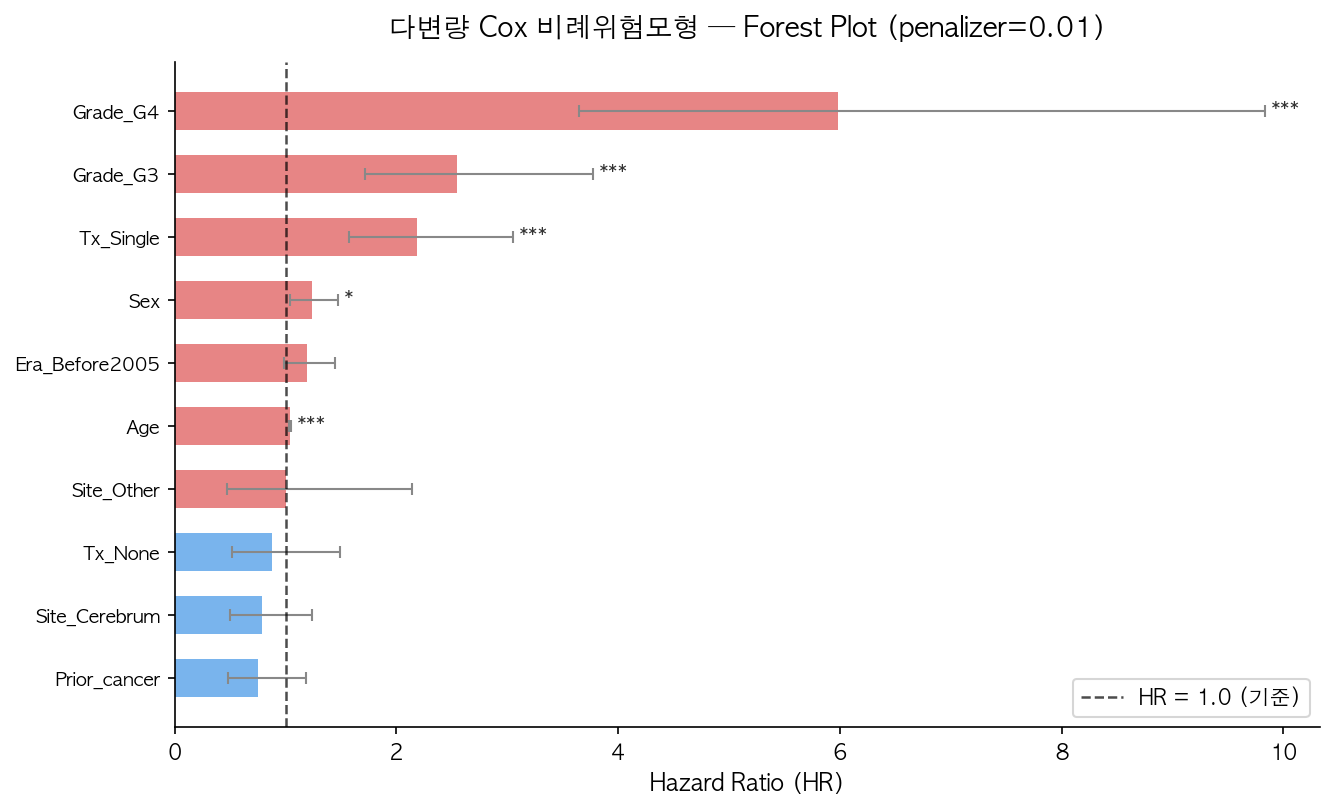

✓ fig_cox_forest_plot.png 저장 완료

✓ cox_multi_result.pkl 저장 완료

STEP 1~4 완료 요약
  최적 penalizer  : 0.01
  CV C-index      : 0.783 ± 0.016
  다변량 포함 변수: 10개
  VIF > 10 제외   : 없음

STEP 5. 비례위험 가정 검정
다변량 Cox (penalizer=0.01) 기준
포함 변수 (10개): ['Age', 'Sex', 'Prior_cancer', 'Grade_G3', 'Grade_G4', 'Site_Cerebrum', 'Site_Other', 'Era_Before2005', 'Tx_Single', 'Tx_None']

-------------------------------------------------------
[ 5-1. Schoenfeld 잔차 검정 ]
귀무가설: 잔차와 시간 간 상관 없음 (비례위험 가정 충족)
p < 0.05 → 가정 위반
-------------------------------------------------------

       Variable     p-value       위반 여부
            Age      0.0004        ★ 위반
 Era_Before2005      0.0125        ★ 위반
       Grade_G3      0.9027          충족
       Grade_G4      0.5606          충족
   Prior_cancer      0.2065          충족
            Sex      0.2387          충족
  Site_Cerebrum      0.6839          충족
     Site_Other      0.6195          충족
        Tx_None      0.0001        ★ 위반
      Tx_Single      0.2584          충족

──────

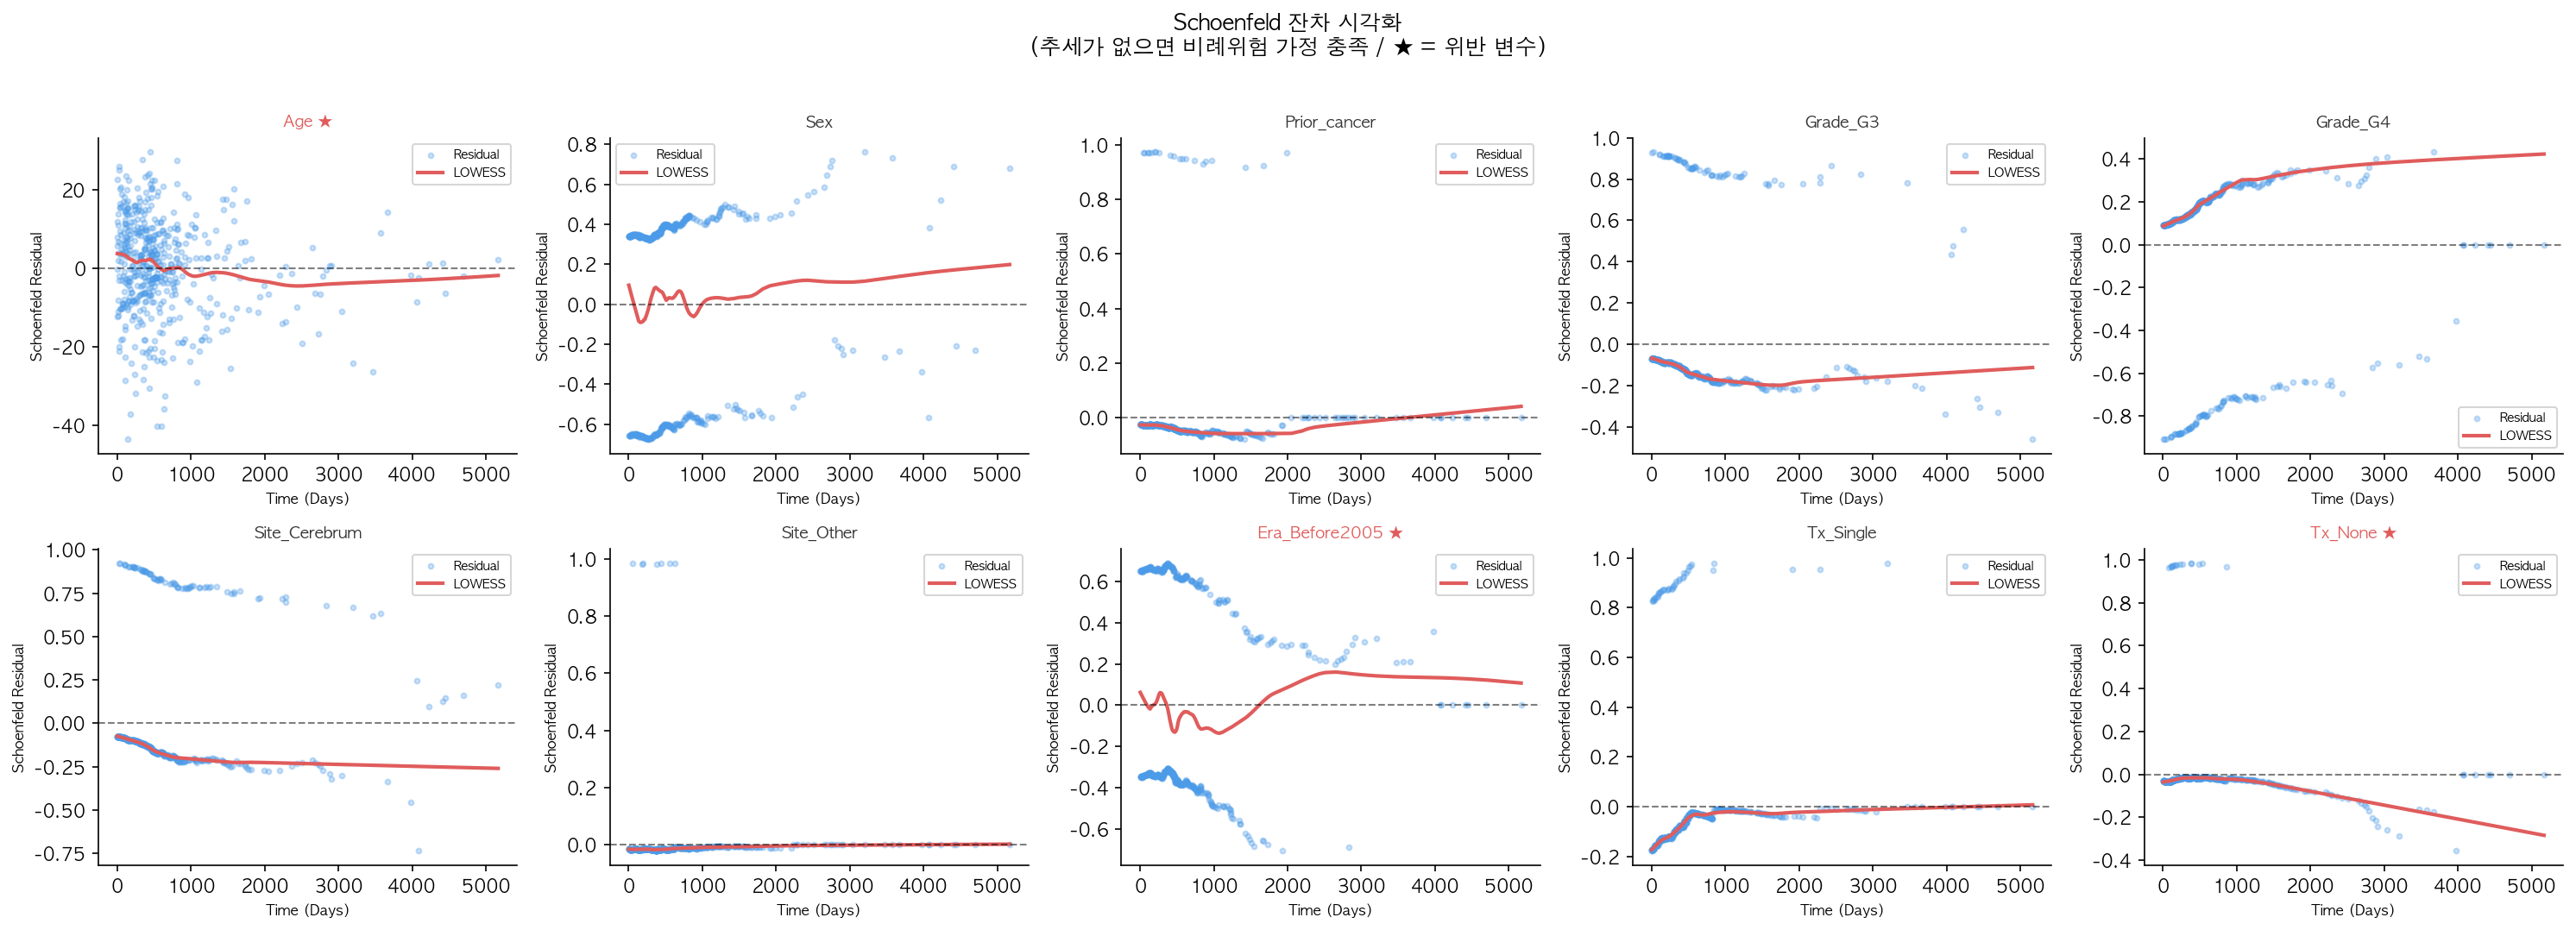

✓ fig_schoenfeld_residuals.png 저장 완료

-------------------------------------------------------
[ 5-3. Log-log Plot ]
선들이 평행하면 비례위험 가정 충족, 교차하면 위반
-------------------------------------------------------


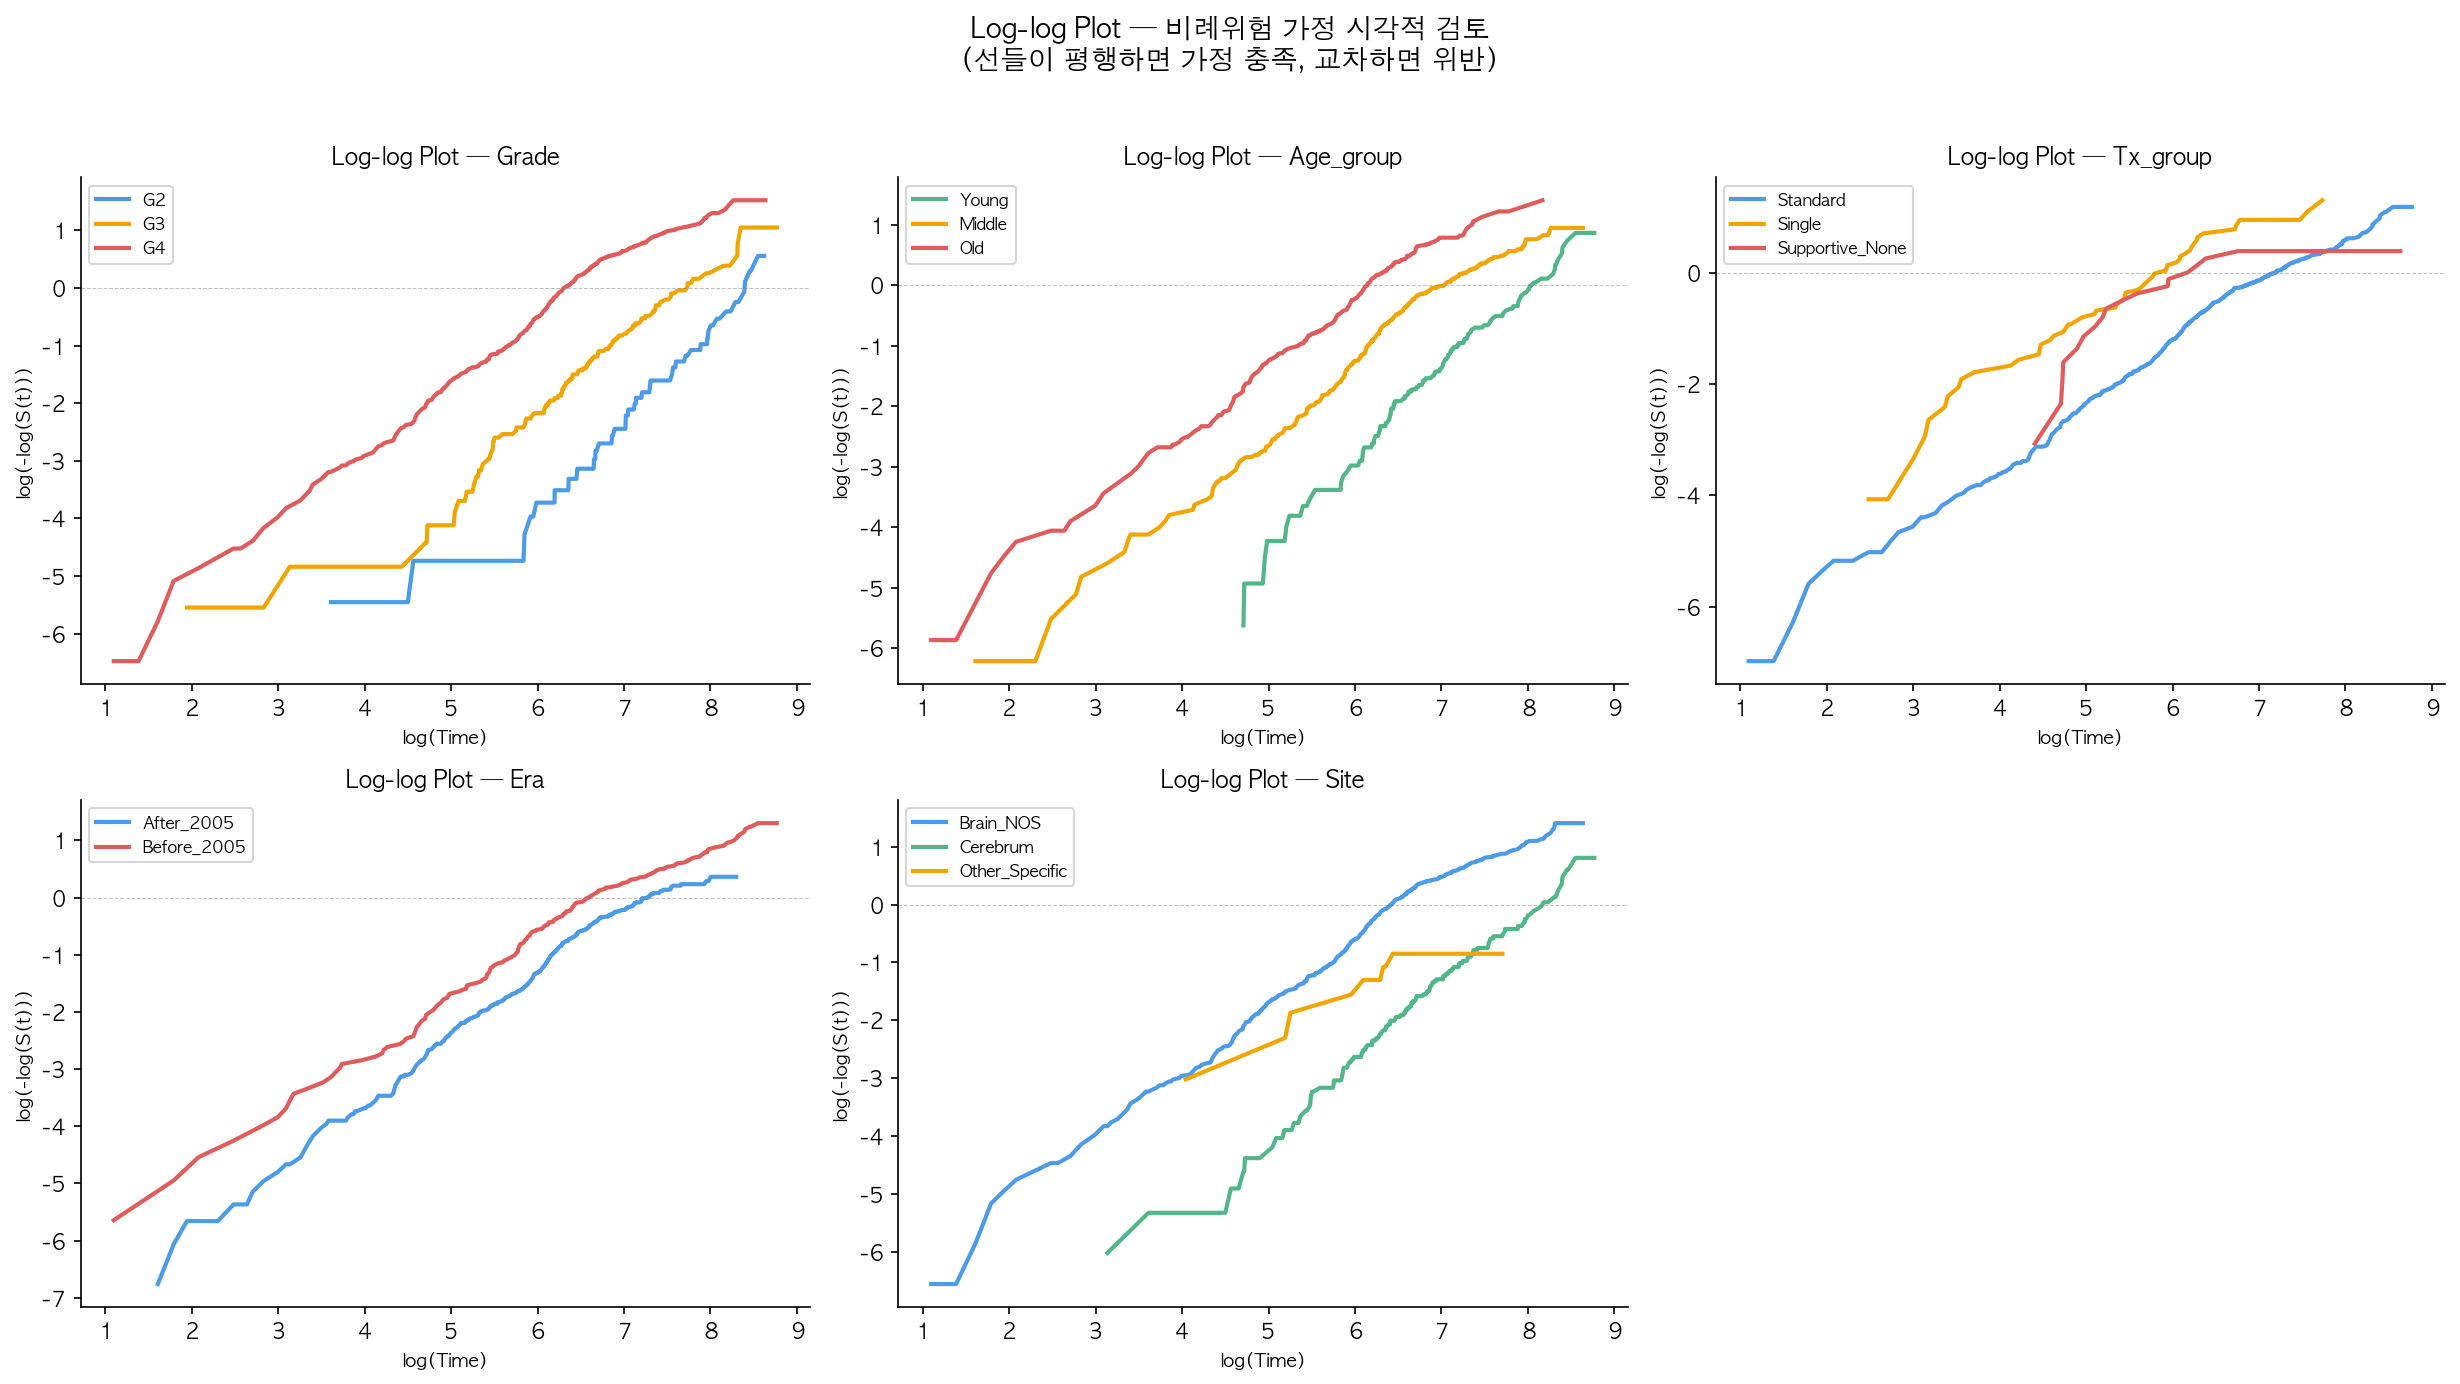

✓ fig_loglog_plot.png 저장 완료

✓ schoenfeld_result.pkl 저장 완료

STEP 5 완료 요약
  위반 변수: ['Age', 'Era_Before2005', 'Tx_None']

  논문 서술 근거:
  'Age, Era_Before2005, Tx_None 변수에서
  비례위험 가정 위반 확인 → ML 모델 적용 근거'

STEP 6. Cox 베이스라인 과적합 검증 + 성능 평가
✓ sksurv Cox 학습 완료 (alpha=0.01)
✓ 평가 시간 구간: 82일 ~ 1559일 (50개)

[ 과적합 검증 — 5-Fold CV ]
  Fold 1: C-index = 0.775
  Fold 2: C-index = 0.765
  Fold 3: C-index = 0.811
  Fold 4: C-index = 0.786
  Fold 5: C-index = 0.779

✓ 5-CV C-index: 0.783 ± 0.015

Model   : Cox PH
──────────────────────────────────────────────────
최적 파라미터 : penalizer=0.01
──────────────────────────────────────────────────
C-index  Train : 0.789
C-index  Test  : 0.800  ← 비교 기준
C-index  5-CV  : 0.783 ± 0.015
IBS      Train : 0.134
IBS      Test  : 0.136
iAUC           : 0.858
──────────────────────────────────────────────────
임상 시점별 AUC:
  365일(1년): 0.845
  730일(2년): 0.844
  1095일(3년): 0.866
──────────────────────────────────────────────────
✓ Train-Test 차이 -0.011 → 과적합 없음
✓ CV-Test 차이 0.017

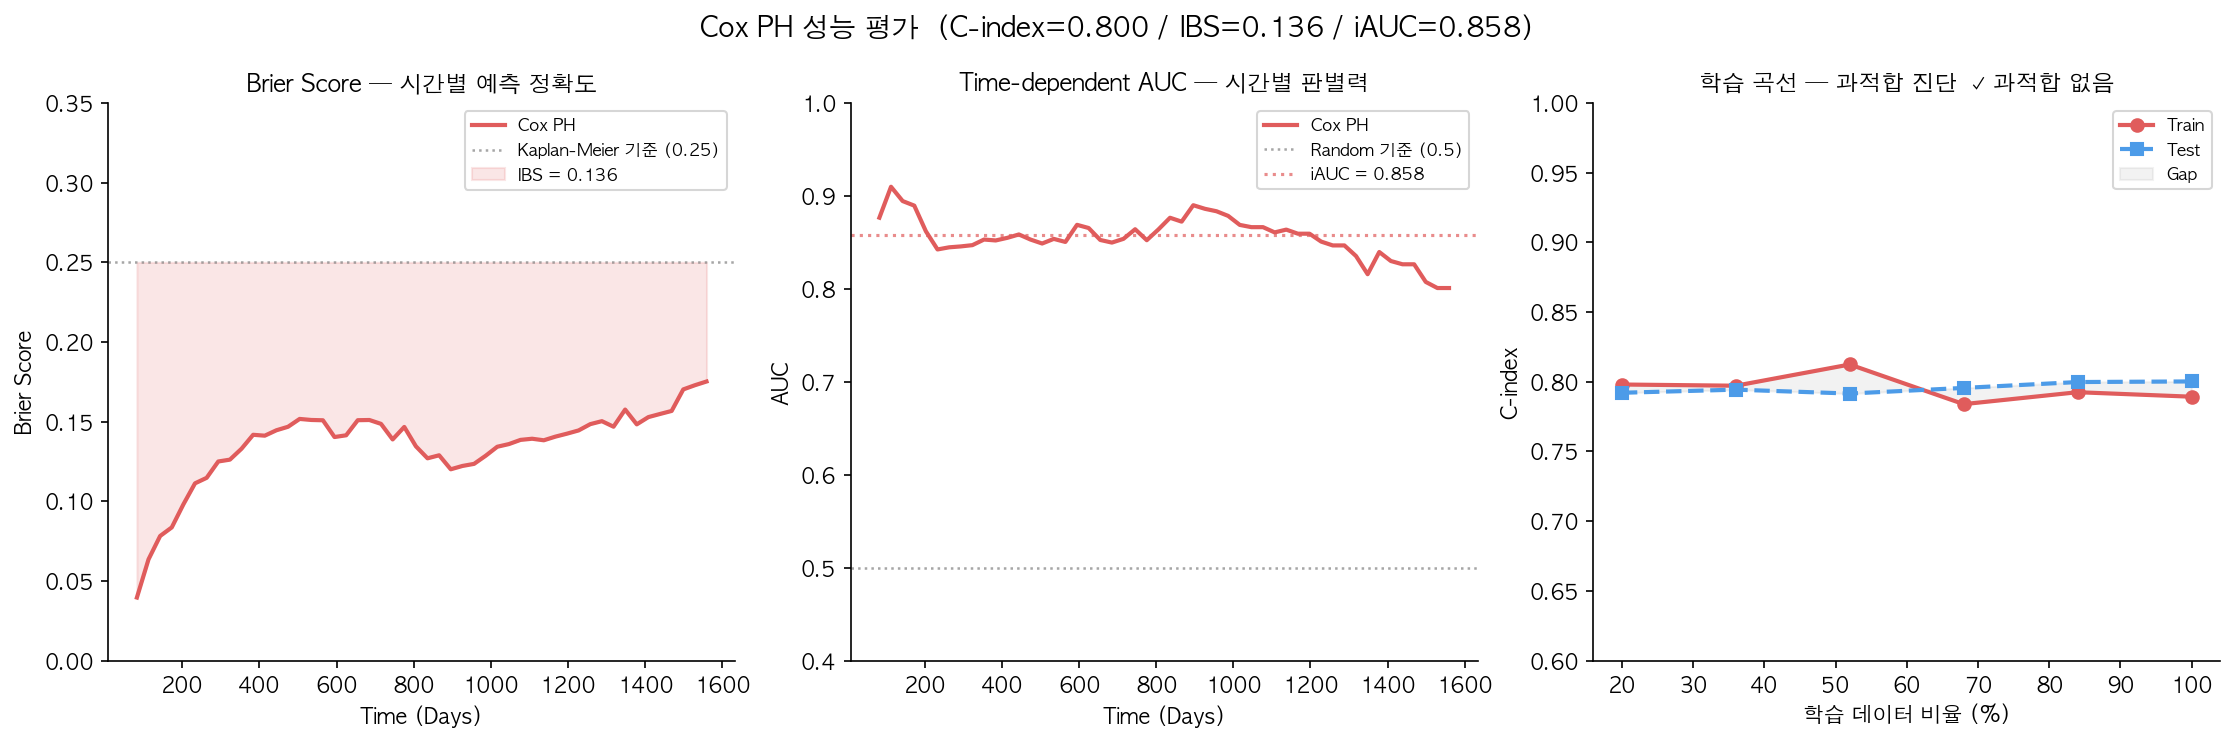

✓ fig_cox_performance.png 저장 완료

✓ cox_performance.pkl 저장 완료

NB 03 완료 — Cox PH 최종 성능 요약
  최적 penalizer   : 0.01
  C-index (Train)  : 0.789
  C-index (Test)   : 0.800
  C-index (5-CV)   : 0.783 ± 0.015
  IBS      (Train) : 0.134
  IBS      (Test)  : 0.136
  iAUC             : 0.858
  위반 변수        : ['Age', 'Era_Before2005', 'Tx_None']

→ 다음: NB 04 ML 모델 (RSF + GBM)


In [1]:
# ============================================================
# NB 03. Cox 비례위험모형 — 베이스라인
# Brain Tumor Survival Analysis — Explainable AI
#
# STEP 1. 데이터 불러오기
# STEP 2. 단변량 Cox 분석
# STEP 3. VIF 다중공선성 검정
# STEP 3.5. Grid Search CV (penalizer 최적화)
# STEP 4. 다변량 Cox 분석
# STEP 5. 비례위험 가정 검정
# STEP 6. 과적합 검증 + 성능 평가
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import warnings
import os
warnings.filterwarnings('ignore')

from lifelines import CoxPHFitter, KaplanMeierFitter
from lifelines.statistics import proportional_hazard_test
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
from statsmodels.nonparametric.smoothers_lowess import lowess
from sklearn.model_selection import StratifiedKFold, ParameterGrid
from sksurv.linear_model import CoxPHSurvivalAnalysis
from sksurv.metrics import (
    concordance_index_censored,
    integrated_brier_score,
    cumulative_dynamic_auc,
    brier_score
)

plt.rcParams.update({
    'font.family'      : 'AppleGothic',
    'axes.unicode_minus': False,
    'figure.dpi'       : 150,
    'savefig.dpi'      : 300,
    'savefig.bbox'     : 'tight',
    'axes.spines.top'  : False,
    'axes.spines.right': False,
})

OUTPUT_DIR = "./outputs/"
MODEL_DIR  = "./outputs/models/"
SEED       = 42
N_FOLDS    = 5
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)
np.random.seed(SEED)

# ============================================================
# STEP 1. 데이터 불러오기
# ============================================================

print("="*55)
print("STEP 1. 데이터 불러오기")
print("="*55)

splits       = joblib.load(MODEL_DIR + "data_splits.pkl")
X_train      = splits['X_train']
X_test       = splits['X_test']
y_train      = splits['y_train']
y_test       = splits['y_test']
df_train     = splits['df_train']
df_test      = splits['df_test']
FEATURE_COLS = splits['feature_cols']

# Cox용 피처 선택 (Age_group 더미 + Treatment 제외)
COX_EXCLUDE  = ['Age_Young', 'Age_Middle', 'Age_Old', 'Treatment']
COX_FEATURES = [c for c in FEATURE_COLS if c not in COX_EXCLUDE]

print(f"Train : {len(X_train):,}명  |  Test : {len(X_test):,}명")
print(f"전체 피처 : {len(FEATURE_COLS)}개  →  Cox 피처 : {len(COX_FEATURES)}개")
print(f"\nCox 피처 목록 ({len(COX_FEATURES)}개):")
for col in COX_FEATURES:
    print(f"  {col}")

# 공통 헬퍼 함수
def make_df_cox(cols, X, y, df=None):
    """
    df_train에 컬럼이 있으면 df 기반으로 구성
    없으면 X_train 기반으로 구성 (안전 처리)
    """
    if df is not None:
        missing = [c for c in cols if c not in df.columns]
        if not missing:
            result = df[cols].copy()
            result['time']  = [t for _, t in y]
            result['event'] = [int(e) for e, _ in y]
            return result
    result = X[cols].copy()
    result['time']  = [t for _, t in y]
    result['event'] = [int(e) for e, _ in y]
    return result

# ============================================================
# STEP 2. 단변량 Cox 분석
# ============================================================

print("\n" + "="*55)
print("STEP 2. 단변량 Cox 분석")
print("="*55)

univariate_results = []
cph_uni = CoxPHFitter()

for col in COX_FEATURES:
    try:
        df_uni = make_df_cox([col], X_train, y_train, df_train)
        cph_uni.fit(
            df_uni,
            duration_col='time',
            event_col='event',
            show_progress=False
        )
        s  = cph_uni.summary
        hr = float(s['exp(coef)'].iloc[0])
        lb = float(s['exp(coef) lower 95%'].iloc[0])
        ub = float(s['exp(coef) upper 95%'].iloc[0])
        p  = float(s['p'].iloc[0])

        univariate_results.append({
            'Variable'   : col,
            'HR'         : round(hr, 3),
            'HR_lower'   : round(lb, 3),
            'HR_upper'   : round(ub, 3),
            '95% CI'     : f"{lb:.3f} – {ub:.3f}",
            'p-value'    : round(p, 4),
            'Significant': '***' if p < 0.001
                           else '**' if p < 0.01
                           else '*'  if p < 0.05
                           else 'ns'
        })
    except Exception as e:
        print(f"  [{col}] 단변량 분석 실패: {e}")

df_univariate = (
    pd.DataFrame(univariate_results)
      .sort_values('p-value')
      .reset_index(drop=True)
)

print(df_univariate[
    ['Variable', 'HR', '95% CI', 'p-value', 'Significant']
].to_string(index=False))

df_univariate.to_csv(
    OUTPUT_DIR + "table3_univariate_cox.csv",
    index=False, encoding='utf-8-sig'
)
print("\n✓ table3_univariate_cox.csv 저장 완료")

sig_vars = df_univariate[
    df_univariate['p-value'] < 0.05
]['Variable'].tolist()
print(f"\n유의 변수 (p < 0.05, 참고용): {sig_vars}")
print("※ 다변량 포함 변수는 VIF 결과 확인 후 결정")

# 단변량 Forest Plot
df_uni_plot = (
    df_univariate
      .sort_values('HR', ascending=True)
      .reset_index(drop=True)
)

fig, ax = plt.subplots(
    figsize=(10, max(5, len(df_uni_plot) * 0.55))
)
colors_uni = [
    '#E05C5C' if hr > 1 else '#4C9BE8'
    for hr in df_uni_plot['HR']
]
ax.barh(
    range(len(df_uni_plot)),
    df_uni_plot['HR'],
    xerr=[
        (df_uni_plot['HR'] - df_uni_plot['HR_lower']).clip(lower=0),
        (df_uni_plot['HR_upper'] - df_uni_plot['HR']).clip(lower=0)
    ],
    color=colors_uni, alpha=0.75,
    error_kw=dict(ecolor='#888888', capsize=3, linewidth=1),
    height=0.6
)
ax.axvline(1.0, color='black', linestyle='--',
           linewidth=1.2, alpha=0.7, label='HR = 1.0 (기준)')
for i, row in df_uni_plot.iterrows():
    if row['Significant'] != 'ns':
        ax.text(row['HR_upper'] + 0.05, i,
                row['Significant'],
                va='center', fontsize=9, color='#333333')
ax.set_yticks(range(len(df_uni_plot)))
ax.set_yticklabels(df_uni_plot['Variable'], fontsize=9)
ax.set_xlabel("Hazard Ratio (HR)", fontsize=11)
ax.set_title("단변량 Cox 비례위험모형 — Forest Plot",
             fontsize=13, fontweight='bold', pad=12)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig(OUTPUT_DIR + "fig_univariate_forest_plot.png")
plt.show()
print("✓ fig_univariate_forest_plot.png 저장 완료")

# ============================================================
# STEP 3. VIF 다중공선성 검정
# ============================================================

print("\n" + "="*55)
print("STEP 3. VIF 다중공선성 검정")
print("="*55)

REFERENCE_CATS = [
    'Grade_G2',
    'Site_BrainNOS',
    'Era_After2005',
    'Tx_Standard',
]

VIF_COLS    = [c for c in COX_FEATURES if c not in REFERENCE_CATS]
X_vif       = X_train[VIF_COLS].copy().astype(float)
X_vif_const = add_constant(X_vif)

vif_results = []
for i, col in enumerate(X_vif.columns):
    try:
        val = variance_inflation_factor(
            X_vif_const.values, i + 1
        )
        vif_results.append({
            'Variable': col,
            'VIF'     : round(val, 2)
        })
    except Exception:
        vif_results.append({'Variable': col, 'VIF': np.nan})

df_vif = (
    pd.DataFrame(vif_results)
      .sort_values('VIF', ascending=False)
      .reset_index(drop=True)
)

print(df_vif.to_string(index=False))
df_vif.to_csv(
    OUTPUT_DIR + "table_vif.csv",
    index=False, encoding='utf-8-sig'
)
print("\n✓ table_vif.csv 저장 완료")

high_vif = df_vif[df_vif['VIF'] > 10]['Variable'].tolist()
if high_vif:
    print(f"\n[주의] VIF > 10 변수: {high_vif}")
    print("→ 다변량 모델에서 추가 제외")
else:
    print("\n✓ VIF > 10 변수 없음 — 다중공선성 문제 없음")

# VIF 시각화
fig, ax = plt.subplots(
    figsize=(9, max(4, len(df_vif) * 0.45))
)
colors_vif = [
    '#E05C5C' if v > 10
    else '#F0A500' if v > 5
    else '#4C9BE8'
    for v in df_vif['VIF']
]
bars = ax.barh(
    range(len(df_vif)),
    df_vif['VIF'],
    color=colors_vif, alpha=0.8, height=0.6
)
ax.axvline(5,  color='#F0A500', linestyle='--',
           linewidth=1.2, alpha=0.8, label='VIF = 5 (주의)')
ax.axvline(10, color='#E05C5C', linestyle='--',
           linewidth=1.2, alpha=0.8, label='VIF = 10 (위험)')
for i, (v, bar) in enumerate(zip(df_vif['VIF'], bars)):
    ax.text(v + 0.05, i, f"{v:.2f}",
            va='center', fontsize=8, color='#333333')
ax.set_yticks(range(len(df_vif)))
ax.set_yticklabels(df_vif['Variable'], fontsize=9)
ax.set_xlabel("VIF", fontsize=11)
ax.set_title("다중공선성 검정 — VIF",
             fontsize=13, fontweight='bold', pad=12)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(OUTPUT_DIR + "fig_vif.png")
plt.show()
print("✓ fig_vif.png 저장 완료")

# 다변량 포함 변수 확정
MULTI_COLS = [c for c in VIF_COLS if c not in high_vif]

print(f"\n기준 범주 제외  : {REFERENCE_CATS}")
if high_vif:
    print(f"VIF 초과 제외  : {high_vif}")
print(f"\n다변량 포함 변수 ({len(MULTI_COLS)}개):")
for col in MULTI_COLS:
    print(f"  {col}")

# ============================================================
# STEP 3.5. Grid Search CV — 최적 penalizer 탐색
# ============================================================

print("\n" + "="*55)
print("STEP 3.5. Grid Search CV — 최적 penalizer 탐색")
print("="*55)
print("모든 모델 방법론 통일: Grid Search + 5-Fold CV")

ALPHA_GRID = [0.001, 0.005, 0.01, 0.05, 0.1, 0.3, 0.5, 1.0]

skf    = StratifiedKFold(
    n_splits=N_FOLDS, shuffle=True, random_state=SEED
)
events = np.array([int(e) for e, _ in y_train])

best_alpha = 0.1
best_cv    = -np.inf
gs_results = []

print(f"탐색 범위: {ALPHA_GRID}")
print(f"총 {len(ALPHA_GRID)}개 × {N_FOLDS}-Fold = "
      f"{len(ALPHA_GRID) * N_FOLDS}번 학습\n")

for alpha in ALPHA_GRID:
    fold_scores = []
    for tr_idx, val_idx in skf.split(
        X_train[MULTI_COLS], events
    ):
        df_tr = make_df_cox(
            MULTI_COLS,
            X_train.iloc[tr_idx],
            y_train[tr_idx],
            df_train.iloc[tr_idx]
            if df_train is not None else None
        )
        try:
            cph_cv = CoxPHFitter(penalizer=alpha)
            cph_cv.fit(
                df_tr,
                duration_col='time',
                event_col='event',
                show_progress=False
            )
            risk = cph_cv.predict_partial_hazard(
                X_train[MULTI_COLS].iloc[val_idx]
            ).values
            c = concordance_index_censored(
                np.array([bool(e) for e, _ in y_train[val_idx]]),
                np.array([t for _, t in y_train[val_idx]]),
                risk
            )[0]
            fold_scores.append(c)
        except Exception:
            fold_scores.append(0.5)

    mean_c = float(np.mean(fold_scores))
    std_c  = float(np.std(fold_scores))
    gs_results.append({
        'alpha'  : alpha,
        'cv_mean': round(mean_c, 4),
        'cv_std' : round(std_c, 4),
    })
    print(f"  alpha={alpha:.3f}  →  "
          f"CV C-index: {mean_c:.3f} ± {std_c:.3f}")

    if mean_c > best_cv:
        best_cv    = mean_c
        best_alpha = alpha

# 최적 alpha의 cv_std 추출
df_gs       = pd.DataFrame(gs_results)
best_cv_std = float(
    df_gs.loc[df_gs['alpha'] == best_alpha, 'cv_std'].values[0]
)

print(f"\n✓ 최적 penalizer : {best_alpha}")
print(f"✓ CV C-index     : {best_cv:.3f} ± {best_cv_std:.3f}")

df_gs.to_csv(
    OUTPUT_DIR + "table_cox_gridsearch.csv",
    index=False, encoding='utf-8-sig'
)
print("✓ table_cox_gridsearch.csv 저장 완료")

# ============================================================
# STEP 4. 다변량 Cox 분석 (최적 penalizer 적용)
# ============================================================

print("\n" + "="*55)
print(f"STEP 4. 다변량 Cox 분석 (penalizer={best_alpha})")
print("="*55)

df_multi_train = make_df_cox(
    MULTI_COLS, X_train, y_train, df_train
)

missing_cols = [
    c for c in MULTI_COLS
    if c not in df_multi_train.columns
]
if missing_cols:
    print(f"[경고] 누락 컬럼: {missing_cols}")
else:
    print(f"✓ 컬럼 확인 완료 ({len(MULTI_COLS)}개)")

cph_multi = CoxPHFitter(penalizer=best_alpha)
cph_multi.fit(
    df_multi_train,
    duration_col='time',
    event_col='event',
    show_progress=False
)

cph_multi.print_summary()

s = cph_multi.summary.copy()
df_multivariate = pd.DataFrame({
    'Variable'   : s.index,
    'HR'         : s['exp(coef)'].round(3),
    'HR_lower'   : s['exp(coef) lower 95%'].round(3),
    'HR_upper'   : s['exp(coef) upper 95%'].round(3),
    '95% CI'     : (s['exp(coef) lower 95%'].round(3).astype(str)
                    + ' – '
                    + s['exp(coef) upper 95%'].round(3).astype(str)),
    'p-value'    : s['p'].round(4),
    'Significant': s['p'].apply(
        lambda p: '***' if p < 0.001
                  else '**' if p < 0.01
                  else '*'  if p < 0.05
                  else 'ns'
    )
}).reset_index(drop=True)

print("\n=== 다변량 Cox 결과 요약 ===")
print(df_multivariate[
    ['Variable', 'HR', '95% CI', 'p-value', 'Significant']
].to_string(index=False))

df_multivariate.to_csv(
    OUTPUT_DIR + "table4_multivariate_cox.csv",
    index=False, encoding='utf-8-sig'
)
print("\n✓ table4_multivariate_cox.csv 저장 완료")

# 다변량 Forest Plot
df_plot = (
    df_multivariate
      .sort_values('HR', ascending=True)
      .reset_index(drop=True)
)

fig, ax = plt.subplots(
    figsize=(9, max(5, len(df_plot) * 0.55))
)
colors_multi = [
    '#E05C5C' if hr > 1 else '#4C9BE8'
    for hr in df_plot['HR']
]
ax.barh(
    range(len(df_plot)),
    df_plot['HR'],
    xerr=[
        (df_plot['HR'] - df_plot['HR_lower']).clip(lower=0),
        (df_plot['HR_upper'] - df_plot['HR']).clip(lower=0)
    ],
    color=colors_multi, alpha=0.75,
    error_kw=dict(ecolor='#888888', capsize=3, linewidth=1),
    height=0.6
)
ax.axvline(1.0, color='black', linestyle='--',
           linewidth=1.2, alpha=0.7, label='HR = 1.0 (기준)')
for i, row in df_plot.iterrows():
    if row['Significant'] != 'ns':
        ax.text(row['HR_upper'] + 0.05, i,
                row['Significant'],
                va='center', fontsize=10, color='#333333')
ax.set_yticks(range(len(df_plot)))
ax.set_yticklabels(df_plot['Variable'], fontsize=9)
ax.set_xlabel("Hazard Ratio (HR)", fontsize=11)
ax.set_title(
    f"다변량 Cox 비례위험모형 — Forest Plot "
    f"(penalizer={best_alpha})",
    fontsize=13, fontweight='bold', pad=12
)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig(OUTPUT_DIR + "fig_cox_forest_plot.png")
plt.show()
print("✓ fig_cox_forest_plot.png 저장 완료")

# 모델 저장 (STEP 5~6에서 재사용)
joblib.dump({
    'cph_multi'      : cph_multi,
    'multi_cols'     : MULTI_COLS,
    'df_multi_train' : df_multi_train,
    'df_multivariate': df_multivariate,
    'cox_features'   : COX_FEATURES,
    'best_alpha'     : best_alpha,
    'best_cv_mean'   : best_cv,
    'best_cv_std'    : best_cv_std,
    'gs_results'     : gs_results,
    'reference_cats' : REFERENCE_CATS,
}, MODEL_DIR + "cox_multi_result.pkl")

print("\n✓ cox_multi_result.pkl 저장 완료")
print(f"\n{'='*55}")
print("STEP 1~4 완료 요약")
print(f"{'='*55}")
print(f"  최적 penalizer  : {best_alpha}")
print(f"  CV C-index      : {best_cv:.3f} ± {best_cv_std:.3f}")
print(f"  다변량 포함 변수: {len(MULTI_COLS)}개")
print(f"  VIF > 10 제외   : {high_vif if high_vif else '없음'}")
print(f"{'='*55}")

# ============================================================
# STEP 5. 비례위험 가정 검정
# ============================================================

print("\n" + "="*55)
print("STEP 5. 비례위험 가정 검정")
print("="*55)
print(f"다변량 Cox (penalizer={best_alpha}) 기준")
print(f"포함 변수 ({len(MULTI_COLS)}개): {MULTI_COLS}")

# ── 5-1. Schoenfeld 잔차 검정 ─────────────────────────────────
print("\n" + "-"*55)
print("[ 5-1. Schoenfeld 잔차 검정 ]")
print("귀무가설: 잔차와 시간 간 상관 없음 (비례위험 가정 충족)")
print("p < 0.05 → 가정 위반")
print("-"*55)

results_ph = proportional_hazard_test(
    cph_multi,
    df_multi_train,
    time_transform='rank'
)

# p 컬럼명 안전 추출
summary_df = results_ph.summary.copy().reset_index()
summary_df.columns = [
    str(c).strip() for c in summary_df.columns
]
if summary_df.columns[0] != 'Variable':
    summary_df = summary_df.rename(
        columns={summary_df.columns[0]: 'Variable'}
    )

p_col = None
for c in summary_df.columns:
    if c.lower() in ['p', 'p-value', 'p_value']:
        p_col = c
        break
if p_col is None:
    num_cols = summary_df.select_dtypes(include=float).columns
    p_col    = num_cols[-1]
    print(f"[참고] p값 컬럼 자동 선택: {p_col}")

summary_df['위반 여부'] = summary_df[p_col].apply(
    lambda p: '★ 위반' if p < 0.05 else '충족'
)
summary_df[p_col] = summary_df[p_col].round(4)

print(f"\n{'Variable':>15s}  {'p-value':>10s}  {'위반 여부':>10s}")
print("="*40)
for _, row in summary_df.iterrows():
    print(f"{row['Variable']:>15s}  "
          f"{row[p_col]:>10.4f}  "
          f"{row['위반 여부']:>10s}")

violated_vars = summary_df[
    summary_df['위반 여부'] == '★ 위반'
]['Variable'].tolist()

print(f"\n{'─'*40}")
if violated_vars:
    print(f"위반 변수 ({len(violated_vars)}개): {violated_vars}")
    print("→ Cox의 시간 불변 가정 미충족")
    print("→ 논문 서사: ML 모델 필요성 근거")
else:
    print("✓ 모든 변수에서 비례위험 가정 충족")

summary_df.to_csv(
    OUTPUT_DIR + "table5_schoenfeld.csv",
    index=False, encoding='utf-8-sig'
)
print("\n✓ table5_schoenfeld.csv 저장 완료")

# ── 5-2. Schoenfeld 잔차 시각화 ──────────────────────────────
print("\n" + "-"*55)
print("[ 5-2. Schoenfeld 잔차 시각화 ]")
print("-"*55)

try:
    residuals = cph_multi.compute_residuals(
        df_multi_train, kind='schoenfeld'
    )
    t_values  = df_multi_train.loc[
        residuals.index, 'time'
    ].values

    avail_cols  = [
        c for c in MULTI_COLS if c in residuals.columns
    ]
    missing_res = [
        c for c in MULTI_COLS if c not in residuals.columns
    ]
    if missing_res:
        print(f"[참고] 잔차 없는 변수: {missing_res}")

    n_cols = min(len(avail_cols), 5)
    n_rows = -(-len(avail_cols) // n_cols)

    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(n_cols * 4, n_rows * 3.5)
    )
    axes = np.array(axes).flatten()

    for ax, col in zip(axes, avail_cols):
        r = residuals[col].values
        ax.scatter(t_values, r,
                   alpha=0.3, s=8, color='#4C9BE8',
                   label='Residual')
        try:
            smooth = lowess(r, t_values, frac=0.3)
            ax.plot(smooth[:, 0], smooth[:, 1],
                    color='#E05C5C', linewidth=2,
                    label='LOWESS')
        except Exception:
            z     = np.polyfit(t_values, r, 1)
            p_fit = np.poly1d(z)
            t_rng = np.linspace(
                t_values.min(), t_values.max(), 100
            )
            ax.plot(t_rng, p_fit(t_rng),
                    color='#E05C5C', linewidth=1.5,
                    linestyle='--', label='Trend')

        ax.axhline(0, color='black', linewidth=1,
                   alpha=0.5, linestyle='--')

        is_violated = col in violated_vars
        title_color = '#E05C5C' if is_violated else '#333333'
        suffix      = ' ★' if is_violated else ''
        ax.set_title(f"{col}{suffix}",
                     fontsize=9, color=title_color,
                     fontweight='bold')
        ax.set_xlabel("Time (Days)", fontsize=8)
        ax.set_ylabel("Schoenfeld Residual", fontsize=8)
        ax.legend(fontsize=7)

    for ax in axes[len(avail_cols):]:
        ax.set_visible(False)

    plt.suptitle(
        "Schoenfeld 잔차 시각화\n"
        "(추세가 없으면 비례위험 가정 충족 / ★ = 위반 변수)",
        fontsize=12, fontweight='bold', y=1.02
    )
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR + "fig_schoenfeld_residuals.png")
    plt.show()
    print("✓ fig_schoenfeld_residuals.png 저장 완료")

except Exception as e:
    print(f"[경고] 잔차 시각화 실패: {e}")

# ── 5-3. Log-log Plot ────────────────────────────────────────
print("\n" + "-"*55)
print("[ 5-3. Log-log Plot ]")
print("선들이 평행하면 비례위험 가정 충족, 교차하면 위반")
print("-"*55)

try:
    df_surv = joblib.load(MODEL_DIR + "df_survival.pkl")
except Exception:
    print("[경고] df_survival.pkl 불러오기 실패")
    df_surv = None

LOG_LOG_VARS = {
    'Grade'    : {
        'order' : ['G2', 'G3', 'G4'],
        'colors': ['#4C9BE8', '#F0A500', '#E05C5C']
    },
    'Age_group': {
        'order' : ['Young', 'Middle', 'Old'],
        'colors': ['#52B788', '#F0A500', '#E05C5C']
    },
    'Tx_group' : {
        'order' : ['Standard', 'Single', 'Supportive_None'],
        'colors': ['#4C9BE8', '#F0A500', '#E05C5C']
    },
    'Era'      : {
        'order' : ['After_2005', 'Before_2005'],
        'colors': ['#4C9BE8', '#E05C5C']
    },
    'Site'     : {
        'order' : ['Brain_NOS', 'Cerebrum', 'Other_Specific'],
        'colors': ['#4C9BE8', '#52B788', '#F0A500']
    },
}

if df_surv is not None:
    avail_vars   = {
        var: cfg for var, cfg in LOG_LOG_VARS.items()
        if var in df_surv.columns
    }
    missing_vars = [
        v for v in LOG_LOG_VARS if v not in df_surv.columns
    ]
    if missing_vars:
        print(f"[참고] df_survival에 없는 변수: {missing_vars}")

    n_vars = len(avail_vars)
    n_cols = min(n_vars, 3)
    n_rows = -(-n_vars // n_cols)

    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(n_cols * 5.5, n_rows * 4.5)
    )
    axes = np.array(axes).flatten()
    kmf  = KaplanMeierFitter()

    for ax, (var, cfg) in zip(axes, avail_vars.items()):
        plotted = False
        for grp, color in zip(cfg['order'], cfg['colors']):
            mask = df_surv[var] == grp
            if mask.sum() < 5:
                continue
            try:
                kmf.fit(
                    df_surv.loc[mask, 'time'],
                    df_surv.loc[mask, 'event'],
                    label=str(grp)
                )
                sf    = kmf.survival_function_
                t     = sf.index.values
                s     = sf.values.flatten()
                valid = (s > 0) & (s < 1) & (t > 0)
                if valid.sum() < 2:
                    continue
                ax.plot(
                    np.log(t[valid]),
                    np.log(-np.log(s[valid])),
                    color=color, linewidth=2, label=str(grp)
                )
                plotted = True
            except Exception as e:
                print(f"  [{var}={grp}] 계산 실패: {e}")

        if plotted:
            ax.set_title(
                f"Log-log Plot — {var}",
                fontsize=11, fontweight='bold'
            )
            ax.set_xlabel("log(Time)", fontsize=9)
            ax.set_ylabel("log(-log(S(t)))", fontsize=9)
            ax.legend(fontsize=8)
            ax.axhline(0, color='gray', linewidth=0.5,
                       linestyle='--', alpha=0.5)
        else:
            ax.set_visible(False)

    for ax in axes[n_vars:]:
        ax.set_visible(False)

    plt.suptitle(
        "Log-log Plot — 비례위험 가정 시각적 검토\n"
        "(선들이 평행하면 가정 충족, 교차하면 위반)",
        fontsize=13, fontweight='bold', y=1.02
    )
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR + "fig_loglog_plot.png")
    plt.show()
    print("✓ fig_loglog_plot.png 저장 완료")
else:
    print("[경고] df_survival 없어서 Log-log Plot 생략")

# STEP 5 결과 저장
joblib.dump({
    'violated_vars' : violated_vars,
    'results_ph_df' : summary_df,
    'schoenfeld_p'  : summary_df.set_index(
        'Variable'
    )[p_col].to_dict(),
}, MODEL_DIR + "schoenfeld_result.pkl")
print("\n✓ schoenfeld_result.pkl 저장 완료")

print(f"\n{'='*55}")
print("STEP 5 완료 요약")
print(f"{'='*55}")
print(f"  위반 변수: {violated_vars if violated_vars else '없음'}")
if violated_vars:
    print(f"\n  논문 서술 근거:")
    print(f"  '{', '.join(violated_vars)} 변수에서")
    print(f"  비례위험 가정 위반 확인 → ML 모델 적용 근거'")
print(f"{'='*55}")

# ============================================================
# STEP 6. 과적합 검증 + 성능 평가
# ============================================================

print("\n" + "="*55)
print("STEP 6. Cox 베이스라인 과적합 검증 + 성능 평가")
print("="*55)

# ── 6-1. sksurv Cox 재학습 ───────────────────────────────────
cox_sksurv = CoxPHSurvivalAnalysis(alpha=best_alpha)
cox_sksurv.fit(X_train[MULTI_COLS], y_train)
print(f"✓ sksurv Cox 학습 완료 (alpha={best_alpha})")

# ── 6-2. 평가 시간 구간 설정 ─────────────────────────────────
t_min = np.percentile([t for _, t in y_test], 10)
t_max = np.percentile([t for _, t in y_test], 90)
times = np.linspace(t_min, t_max, 50)
print(f"✓ 평가 시간 구간: {t_min:.0f}일 ~ {t_max:.0f}일 (50개)")

CLINICAL_TIMES = [365, 730, 1095]

# ── 6-3. Train 성능 ──────────────────────────────────────────
risk_train   = cox_sksurv.predict(X_train[MULTI_COLS])
c_train      = concordance_index_censored(
    y_train['event'], y_train['time'], risk_train
)[0]
sf_train     = cox_sksurv.predict_survival_function(
    X_train[MULTI_COLS]
)
sm_train     = np.row_stack([fn(times) for fn in sf_train])
ibs_train    = integrated_brier_score(
    y_train, y_train, sm_train, times
)

# ── 6-4. Test 성능 ───────────────────────────────────────────
risk_test    = cox_sksurv.predict(X_test[MULTI_COLS])
c_test       = concordance_index_censored(
    y_test['event'], y_test['time'], risk_test
)[0]
sf_test      = cox_sksurv.predict_survival_function(
    X_test[MULTI_COLS]
)
sm_test      = np.row_stack([fn(times) for fn in sf_test])
ibs_test     = integrated_brier_score(
    y_train, y_test, sm_test, times
)
auc_scores, iauc = cumulative_dynamic_auc(
    y_train, y_test, risk_test, times
)
_, bs_scores = brier_score(y_train, y_test, sm_test, times)

# ── 6-5. 임상 시점별 AUC ─────────────────────────────────────
te_times     = np.array([t for _, t in y_test])
clinical_auc = {}
for t in CLINICAL_TIMES:
    if t <= te_times.min() or t >= te_times.max():
        continue
    try:
        auc, _ = cumulative_dynamic_auc(
            y_train, y_test, risk_test,
            np.array([float(t)])
        )
        clinical_auc[t] = round(float(auc[0]), 3)
    except Exception:
        clinical_auc[t] = None

# ── 6-6. 5-Fold CV 과적합 검증 (NB 04와 동일한 독립 검증) ────
print("\n[ 과적합 검증 — 5-Fold CV ]")
cv_scores = []
for fold, (tr_idx, val_idx) in enumerate(
    skf.split(X_train[MULTI_COLS], events)
):
    cox_cv = CoxPHSurvivalAnalysis(alpha=best_alpha)
    cox_cv.fit(
        X_train[MULTI_COLS].iloc[tr_idx],
        y_train[tr_idx]
    )
    c_val = concordance_index_censored(
        y_train[val_idx]['event'],
        y_train[val_idx]['time'],
        cox_cv.predict(X_train[MULTI_COLS].iloc[val_idx])
    )[0]
    cv_scores.append(c_val)
    print(f"  Fold {fold+1}: C-index = {c_val:.3f}")

cv_mean = float(np.mean(cv_scores))
cv_std  = float(np.std(cv_scores))
print(f"\n✓ 5-CV C-index: {cv_mean:.3f} ± {cv_std:.3f}")

# ── 6-7. 학습 곡선 ───────────────────────────────────────────
train_sizes   = np.linspace(0.2, 1.0, 6)
lc_train_arr, lc_test_arr = [], []

for size in train_sizes:
    n   = max(int(len(X_train) * size), 50)
    idx = np.random.choice(len(X_train), n, replace=False)
    cox_lc = CoxPHSurvivalAnalysis(alpha=best_alpha)
    cox_lc.fit(
        X_train[MULTI_COLS].iloc[idx], y_train[idx]
    )
    lc_train_arr.append(concordance_index_censored(
        y_train[idx]['event'], y_train[idx]['time'],
        cox_lc.predict(X_train[MULTI_COLS].iloc[idx])
    )[0])
    lc_test_arr.append(concordance_index_censored(
        y_test['event'], y_test['time'],
        cox_lc.predict(X_test[MULTI_COLS])
    )[0])

# ── 6-8. 성능 요약 출력 (NB 04와 동일한 형식) ────────────────
diff    = c_train - c_test
cv_diff = abs(cv_mean - c_test)

print(f"\n{'='*50}")
print(f"Model   : Cox PH")
print(f"{'─'*50}")
print(f"최적 파라미터 : penalizer={best_alpha}")
print(f"{'─'*50}")
print(f"C-index  Train : {c_train:.3f}")
print(f"C-index  Test  : {c_test:.3f}  ← 비교 기준")
print(f"C-index  5-CV  : {cv_mean:.3f} ± {cv_std:.3f}")
print(f"IBS      Train : {ibs_train:.3f}")
print(f"IBS      Test  : {ibs_test:.3f}")
print(f"iAUC           : {iauc:.3f}")
print(f"{'─'*50}")
print(f"임상 시점별 AUC:")
for t, auc_v in clinical_auc.items():
    print(f"  {t}일({t//365}년): {auc_v}")
print(f"{'─'*50}")
print(f"{'✓' if diff <= 0.05 else '[주의]'} "
      f"Train-Test 차이 {diff:.3f} → "
      f"과적합 {'없음' if diff <= 0.05 else '의심'}")
print(f"{'✓' if cv_diff < 0.03 else '[주의]'} "
      f"CV-Test 차이 {cv_diff:.3f}")
print(f"{'='*50}")

# ── 6-9. 성능 시각화 (NB 04와 동일한 구조) ───────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle(
    f"Cox PH 성능 평가  "
    f"(C-index={c_test:.3f} / "
    f"IBS={ibs_test:.3f} / "
    f"iAUC={iauc:.3f})",
    fontsize=13, fontweight='bold'
)

# Brier Score
ax = axes[0]
ax.plot(times, bs_scores, color='#E05C5C',
        linewidth=2, label='Cox PH')
ax.axhline(0.25, color='gray', linestyle=':',
           linewidth=1.2, alpha=0.7,
           label='Kaplan-Meier 기준 (0.25)')
ax.fill_between(
    times, bs_scores, 0.25,
    where=[b < 0.25 for b in bs_scores],
    alpha=0.15, color='#E05C5C',
    label=f'IBS = {ibs_test:.3f}'
)
ax.set_title("Brier Score — 시간별 예측 정확도",
             fontsize=11, fontweight='bold')
ax.set_xlabel("Time (Days)")
ax.set_ylabel("Brier Score")
ax.set_ylim(0, 0.35)
ax.legend(fontsize=8)

# Time-dependent AUC
ax = axes[1]
ax.plot(times, auc_scores, color='#E05C5C',
        linewidth=2, label='Cox PH')
ax.axhline(0.5, color='gray', linestyle=':',
           linewidth=1.2, alpha=0.7,
           label='Random 기준 (0.5)')
ax.axhline(iauc, color='#E05C5C', linestyle=':',
           linewidth=1.5, alpha=0.7,
           label=f'iAUC = {iauc:.3f}')
ax.set_title("Time-dependent AUC — 시간별 판별력",
             fontsize=11, fontweight='bold')
ax.set_xlabel("Time (Days)")
ax.set_ylabel("AUC")
ax.set_ylim(0.4, 1.0)
ax.legend(fontsize=8)

# 학습 곡선
ax = axes[2]
pct = train_sizes * 100
ax.plot(pct, lc_train_arr, 'o-',
        color='#E05C5C', linewidth=2, label='Train')
ax.plot(pct, lc_test_arr, 's--',
        color='#4C9BE8', linewidth=2, label='Test')
ax.fill_between(pct, lc_train_arr, lc_test_arr,
                alpha=0.1, color='gray', label='Gap')
status = '✓ 과적합 없음' if diff <= 0.05 else '[주의]'
ax.set_title(f"학습 곡선 — 과적합 진단  {status}",
             fontsize=11, fontweight='bold')
ax.set_xlabel("학습 데이터 비율 (%)")
ax.set_ylabel("C-index")
ax.set_ylim(0.6, 1.0)
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(OUTPUT_DIR + "fig_cox_performance.png")
plt.show()
print("✓ fig_cox_performance.png 저장 완료")

# ── 6-10. 최종 저장 ──────────────────────────────────────────
cox_performance = {
    'Model'  : 'Cox PH',
    'C-index': round(c_test, 3),
    'IBS'    : round(ibs_test, 3),
    'iAUC'   : round(float(iauc), 3),
}

joblib.dump({
    'performance'    : cox_performance,
    'cox_sksurv'     : cox_sksurv,
    'times'          : times,
    'bs_scores'      : bs_scores,
    'auc_scores'     : auc_scores,
    'surv_matrix'    : sm_test,
    'multi_cols'     : MULTI_COLS,
    'cv_mean'        : cv_mean,
    'cv_std'         : cv_std,
    'best_alpha'     : best_alpha,
    'c_index_train'  : round(c_train, 3),
    'c_index_test'   : round(c_test, 3),
    'ibs_train'      : round(ibs_train, 3),
    'ibs_test'       : round(ibs_test, 3),
    'clinical_auc'   : clinical_auc,
    'lc_train'       : lc_train_arr,
    'lc_test'        : lc_test_arr,
    'train_sizes'    : train_sizes,
    'violated_vars'  : violated_vars,
}, MODEL_DIR + "cox_performance.pkl")

print("\n✓ cox_performance.pkl 저장 완료")

# 최종 요약
print(f"\n{'='*55}")
print("NB 03 완료 — Cox PH 최종 성능 요약")
print(f"{'='*55}")
print(f"  최적 penalizer   : {best_alpha}")
print(f"  C-index (Train)  : {c_train:.3f}")
print(f"  C-index (Test)   : {c_test:.3f}")
print(f"  C-index (5-CV)   : {cv_mean:.3f} ± {cv_std:.3f}")
print(f"  IBS      (Train) : {ibs_train:.3f}")
print(f"  IBS      (Test)  : {ibs_test:.3f}")
print(f"  iAUC             : {iauc:.3f}")
print(f"  위반 변수        : "
      f"{violated_vars if violated_vars else '없음'}")
print(f"{'='*55}")
print("\n→ 다음: NB 04 ML 모델 (RSF + GBM)")